In [1]:
# imports and settings
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    NormativeModel,
    NormData,
    SHASHbLikelihood,
    make_prior,
    plot_centiles,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)

In [2]:
# Datasets 
meta_dir = Path("/home/traaffneu/bersal/digitalrodent/data/MetaData")
dr_dir = Path("/home/traaffneu/bersal/digitalrodent/results/dual_regression")

# name -> (metadata file, DR file). Check the names in the folders!
datasets = {
    "3xTG":          ("3xTGMD.csv", "3xTG.csv"),
    "Alvino":           ("AlvinoMD.csv", "Alvino.csv"),
    "Awake":         ("AwakeMD.csv", "Awake.csv"),
    "Awake_Rest":    ("Awake_RestMD.csv", "Awake_Rest.csv"),
    "Douglas":       ("DouglasMD.csv", "Douglas.csv"),
    "Env_Enrichment":   ("Env_EnrichmentMD.csv", "Env_Enrichment.csv"),
    "Florida":          ("FloridaMD.csv", "Florida.csv"),
    "Longitudinal":     ("LongitudinalMD.csv", "Longitudinal.csv"),
    "MPTP":          ("MPTPMD.csv", "MPTP.csv"),
    "Psilocybin":    ("PsilocybinMD.csv", "Psilocybin.csv"),
    "Psilocybin_Pilot": ("Psilocybin_PilotMD.csv", "Psilocybin_Pilot.csv"),
    "Sexdifference": ("SexdifferenceMD.csv", "Sexdifference.csv"),
}

exclude = []  # e.g. ["Awake"] to run without it
datasets = {k: v for k, v in datasets.items() if k not in exclude}

# Load metadata
meta_parts = []
for name, (meta_file, _) in datasets.items():
    part = pd.read_csv(meta_dir / meta_file, sep="\t")
    part["dataset"] = name
    meta_parts.append(part[["dataset", "Participant_Id", "Sex"]])

meta_df = pd.concat(meta_parts, ignore_index=True)

# Same formats for every dataset: ID as integer, sex as M/F
meta_df["Participant_Id"] = (
    meta_df["Participant_Id"].astype(str)
    .str.replace("sub-", "", regex=False)
    .str.split("_").str[0]
    .str.replace(r"(?<!\d)0+(?=\d)", "", regex=True)
)
meta_df["Sex"] = meta_df["Sex"].astype(str).str.strip().str.upper().str[0]

# One sex value per mouse
sex_df = meta_df.drop_duplicates()
assert not sex_df.duplicated(["dataset", "Participant_Id"]).any(), "some mouse has conflicting sex values"

print(sex_df.groupby("dataset")["Sex"].value_counts(dropna=False))

#Load DR components
dr_parts = []
for name, (_, dr_file) in datasets.items():
    # Comma-separated, with spaces before the commas
    part = pd.read_csv(dr_dir / dr_file, sep=r"\s*,\s*", engine="python")
    part["dataset"] = name
    dr_parts.append(part)

dr_df = pd.concat(dr_parts, ignore_index=True)

comp_cols = [c for c in dr_df.columns if c.startswith("comp")]
dr_df[comp_cols] = dr_df[comp_cols].apply(pd.to_numeric)

#ids = dr_df["subject"].str.extract(r"sub-(\d+)")[0]

#print("Scans without a sub-XXXX ID per dataset:")
#print(dr_df[ids.isna()].groupby("dataset").size())

# Example subject names from each dataset
#for name, group in dr_df.groupby("dataset"):
    #print(name, group["subject"].head(3).tolist())

# sub-0100100_ses-1_... -> 100100, to match the metadata
dr_df["Participant_Id"] = (
    dr_df["subject"].astype(str)
    .str.replace("sub-", "", regex=False)
    .str.split("_").str[0]
    .str.replace(r"(?<!\d)0+(?=\d)", "", regex=True)
)

# Sexdifference: S041 is labelled C10 in the DR file instead of C11 (typo)
dr_df.loc[(dr_df["dataset"] == "Sexdifference") & (dr_df["Participant_Id"] == "C10S41"), "Participant_Id"] = "C11S41"

print(dr_df.groupby("dataset").size())
display(dr_df.head())

dataset           Sex
3xTG              M        8
Alvino            M       14
                  F        8
Awake             M      110
                  F       88
                  NaN     10
Awake_Rest        F       28
Douglas           M       15
Env_Enrichment    F       23
                  M       16
Florida           M        6
                  F        6
Longitudinal      F       36
                  M       34
MPTP              M        9
Psilocybin        M       15
Psilocybin_Pilot  M       24
Sexdifference     M       30
                  F       30
Name: count, dtype: int64
dataset
3xTG                  21
Alvino                22
Awake               1552
Awake_Rest           171
Douglas               20
Env_Enrichment        39
Florida               12
Longitudinal          70
MPTP                   9
Psilocybin            15
Psilocybin_Pilot      24
Sexdifference         60
dtype: int64


,subject,comp1,comp2,comp3,comp4,comp5,comp6,comp7,comp8,comp9,...,comp11,comp12,comp13,comp14,comp15,comp16,comp17,comp18,dataset,Participant_Id
0,sub-jgrADc3NT2_ses-1,0.034176,0.028537,0.020529,0.028063,0.022301,0.028370,0.026070,0.017483,0.024060,...,0.031536,0.022758,0.022596,0.019597,0.026202,0.019869,0.039633,0.013966,3xTG,jgrADc3NT2
1,sub-jgrADc41L_ses-1,0.075112,0.082204,0.105974,0.073857,0.047173,0.047234,0.083780,0.055192,0.072260,...,0.051011,0.049006,0.045647,0.052205,0.067123,0.051313,0.045848,0.037689,3xTG,jgrADc41L
2,sub-jgrADc41L_ses-2,0.073799,0.059524,0.059568,0.061030,0.039751,0.045718,0.064371,0.071061,0.054082,...,0.040905,0.054531,0.058099,0.049208,0.050704,0.032335,0.039005,0.035732,3xTG,jgrADc41L
3,sub-jgrADc41R_ses-1,0.074200,0.088724,0.088600,0.057482,0.039827,0.047728,0.054884,0.057841,0.061516,...,0.046683,0.045346,0.057442,0.067564,0.054424,0.049527,0.036896,0.038081,3xTG,jgrADc41R
4,sub-jgrADc41R_ses-2,0.082977,0.065227,0.063021,0.066548,0.046082,0.042792,0.057278,0.058982,0.065395,...,0.059343,0.058867,0.041382,0.047786,0.046065,0.052247,0.037485,0.039366,3xTG,jgrADc41R


In [3]:
# Merge and checks
# Merge on dataset + ID, so equal IDs from different sites never mix
df = dr_df.merge(sex_df, on=["dataset", "Participant_Id"], how="left")
df["sex_encoded"] = df["Sex"].map({"M": 0, "F": 1}).astype("float64")
df["mouse_id"] = df["dataset"] + "_" + df["Participant_Id"].astype(str)

print(df["Sex"].value_counts(dropna=False))
print(len(df), "scans,", df["mouse_id"].nunique(), "mice")

# Mice not found in the metadata
unmatched = df.loc[df["Sex"].isna(), ["dataset", "mouse_id"]].drop_duplicates()
print("Unmatched mice per dataset:")
print(unmatched.groupby("dataset").size())

# --- temporary checks ---

print(meta_df.loc[meta_df["Participant_Id"].str.contains("c11", case=False), ["dataset", "Participant_Id"]])
print(meta_df.loc[meta_df["Participant_Id"].str.contains("S41"), ["dataset", "Participant_Id"]])

print(df.loc[df["Sex"].isna(), ["dataset", "Participant_Id"]].drop_duplicates())

# Awake_Rest: jgrAesAWc11L has no match in the metadata, dropped by the dropna below
print((dr_df["Participant_Id"] == "jgrAesAWc11L").sum(), "scans of jgrAesAWc11L")

df = df.dropna(subset=["Sex"] + comp_cols)

# Mice per dataset and sex
mice = df[["mouse_id", "dataset", "Sex"]].drop_duplicates()
print(pd.crosstab(mice["dataset"], mice["Sex"]))

# Scans per mouse
print(df.groupby("mouse_id").size().describe())

Sex
M      993
F      924
NaN     98
Name: count, dtype: int64
2015 scans, 464 mice
Unmatched mice per dataset:
dataset
3xTG             11
Awake_Rest        1
Longitudinal     35
Sexdifference     1
dtype: int64
            dataset      Participant_Id
1618     Awake_Rest      jgrAesAWc11R1L
1619     Awake_Rest      jgrAesAWc11R1L
1620     Awake_Rest      jgrAesAWc11R1L
1621     Awake_Rest      jgrAesAWc11R1L
1622     Awake_Rest      jgrAesAWc11R1L
1623     Awake_Rest      jgrAesAWc11R1L
1624     Awake_Rest        jgrAesAWc11R
1625     Awake_Rest        jgrAesAWc11R
1626     Awake_Rest        jgrAesAWc11R
1627     Awake_Rest        jgrAesAWc11R
1628     Awake_Rest        jgrAesAWc11R
1629     Awake_Rest        jgrAesAWc11R
1666     Awake_Rest       jgrAesISOc11L
1667     Awake_Rest       jgrAesISOc11L
1668     Awake_Rest       jgrAesISOc11L
1669     Awake_Rest     jgrAesISOc11R1L
1670     Awake_Rest     jgrAesISOc11R1L
1671     Awake_Rest     jgrAesISOc11R1L
1672     Awake_Rest     jgr

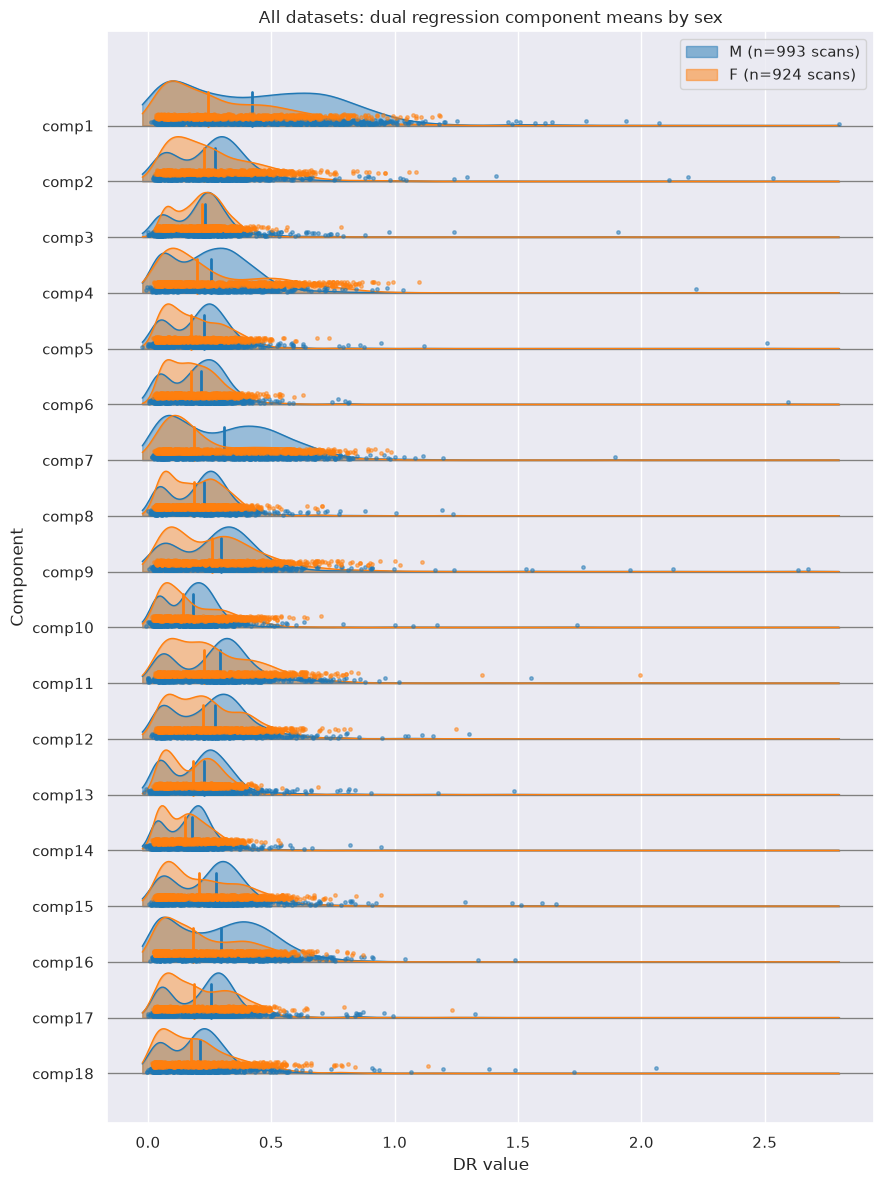

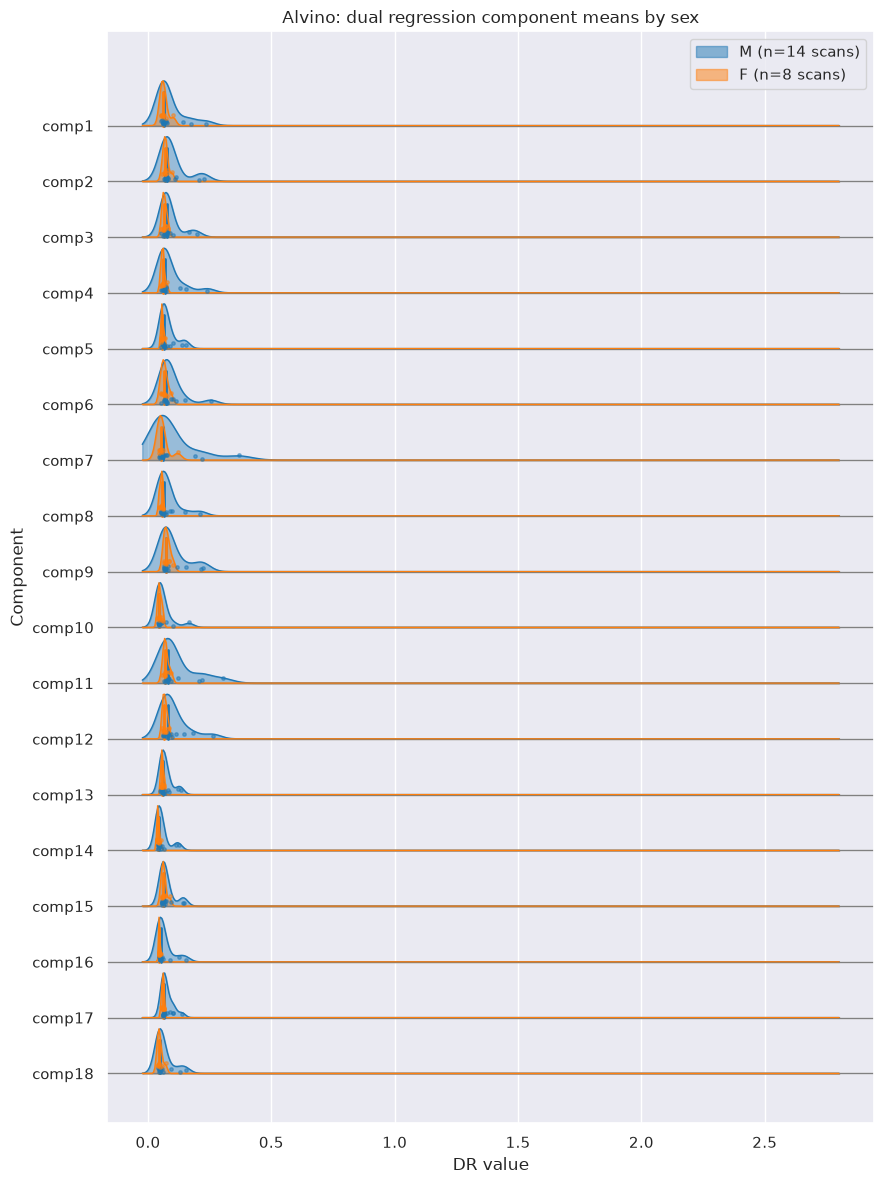

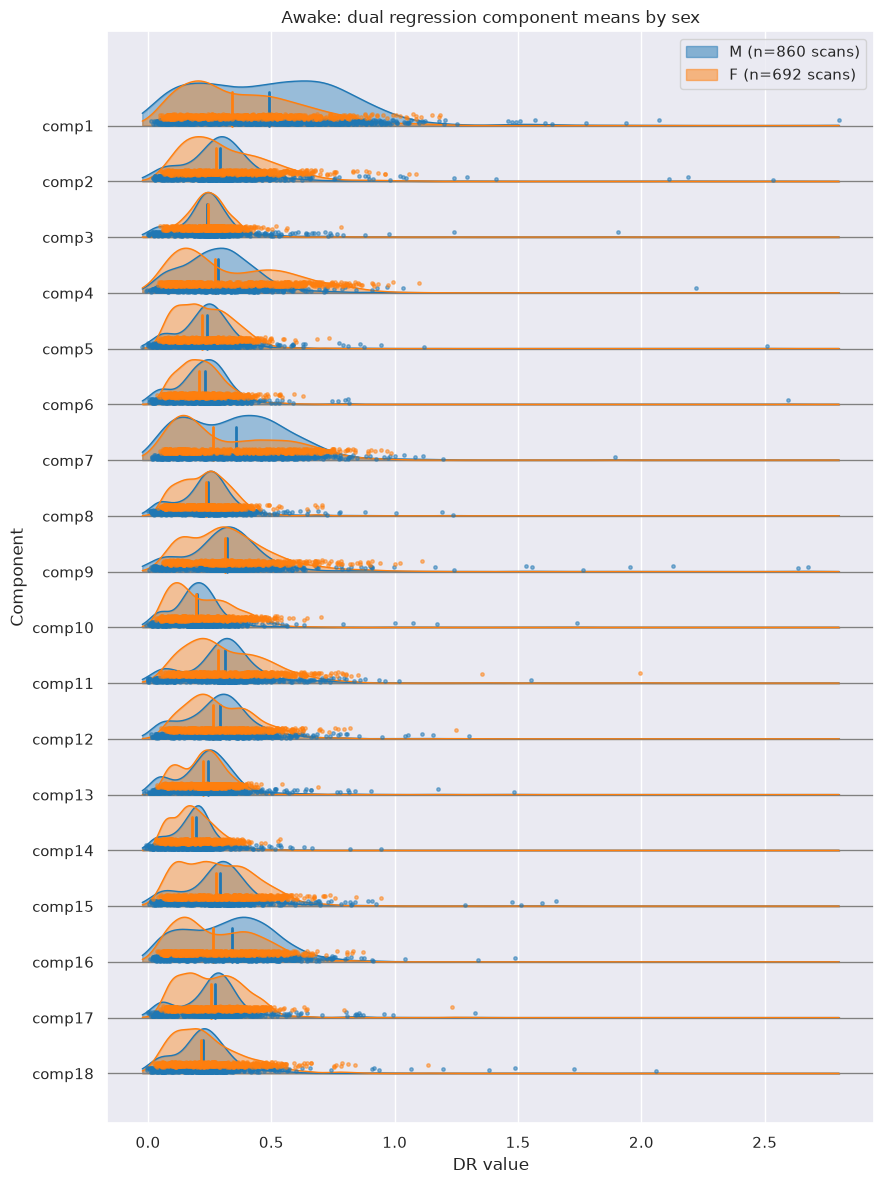

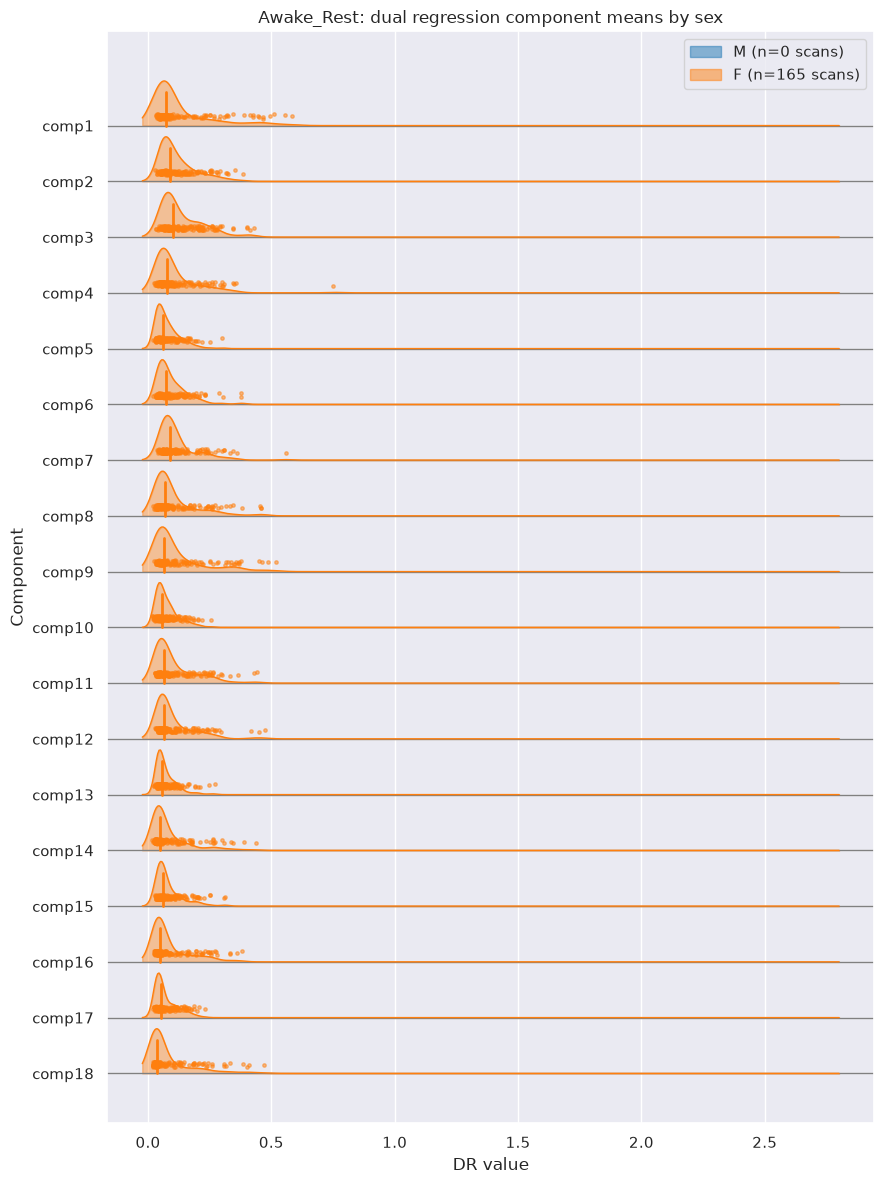

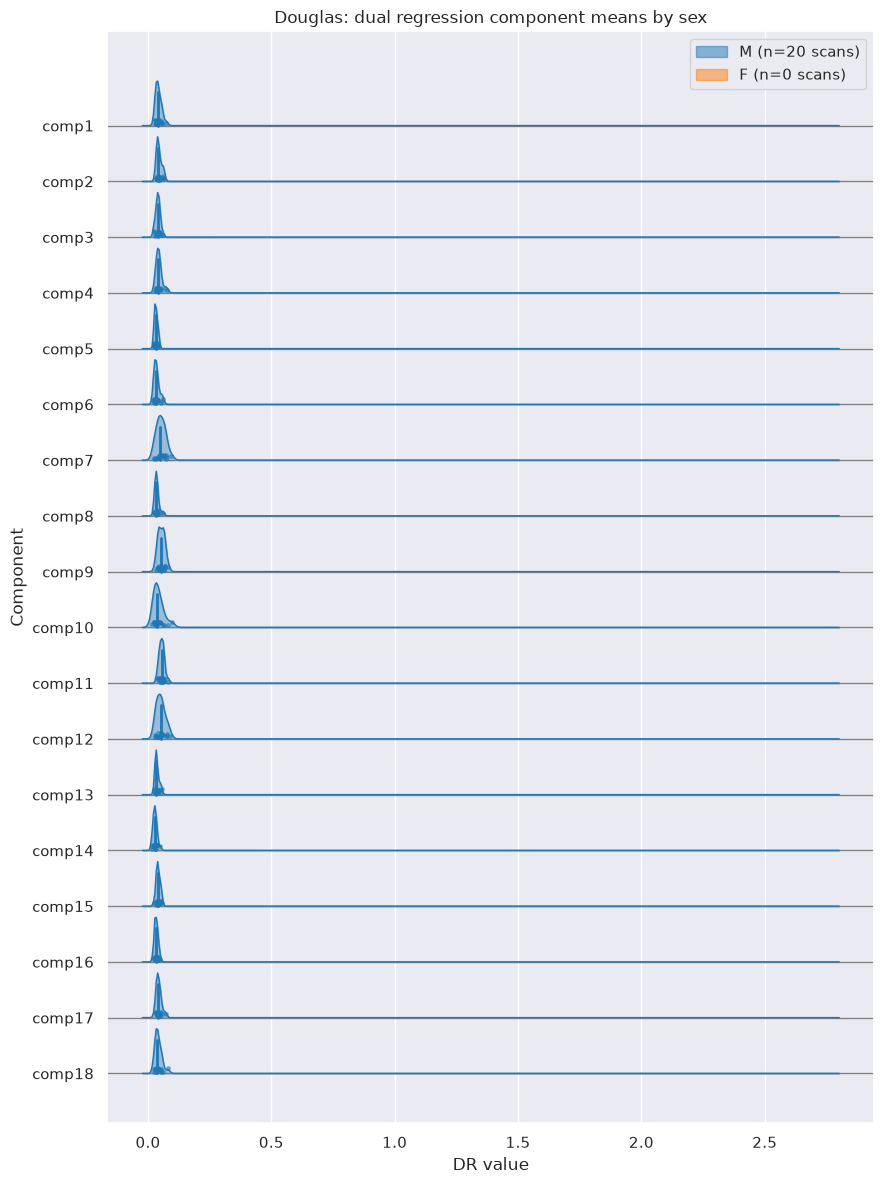

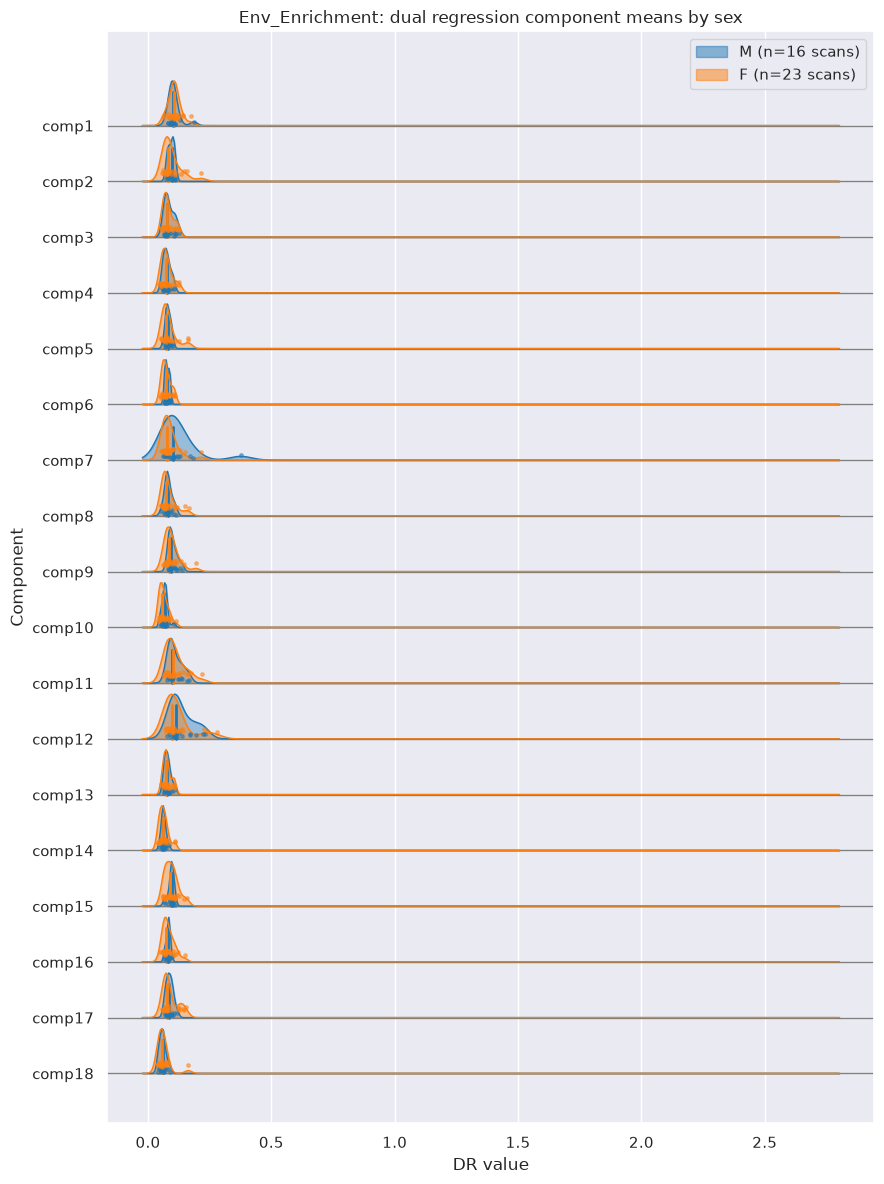

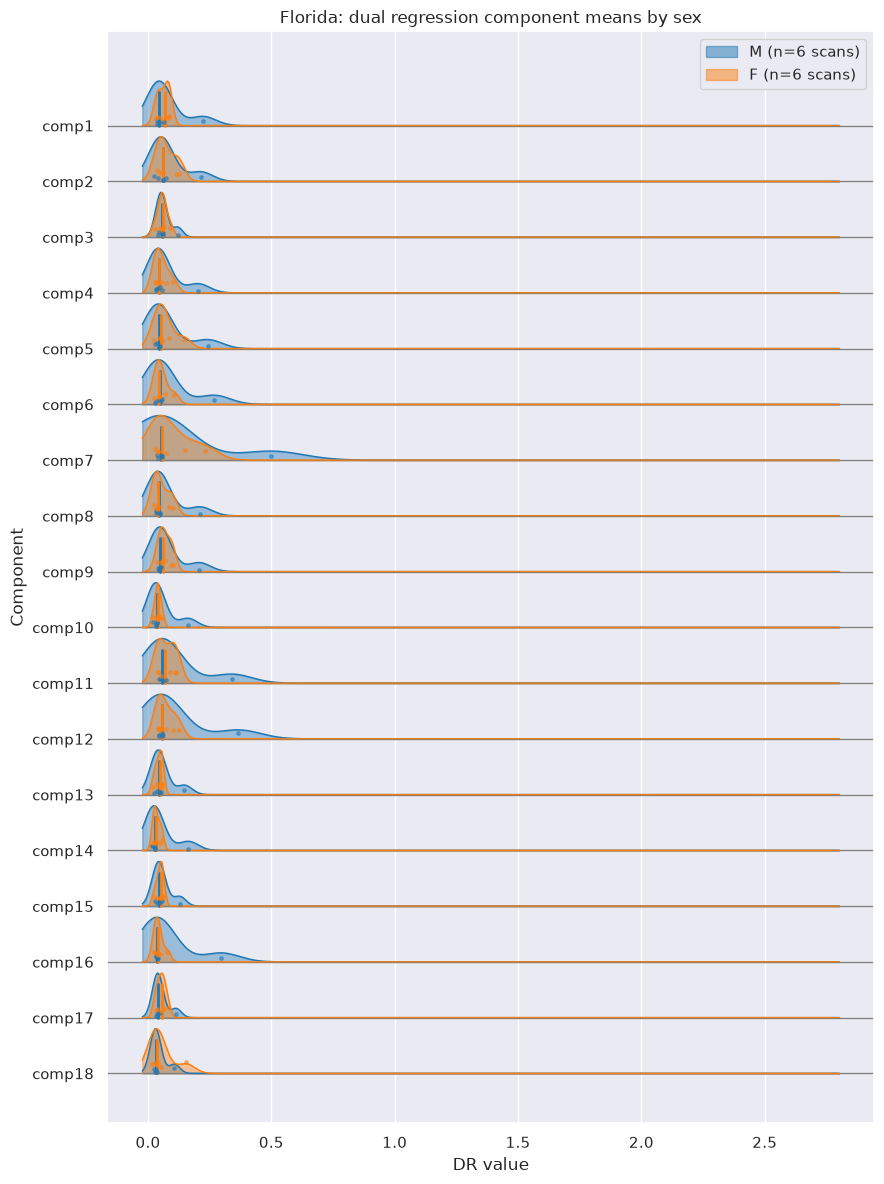

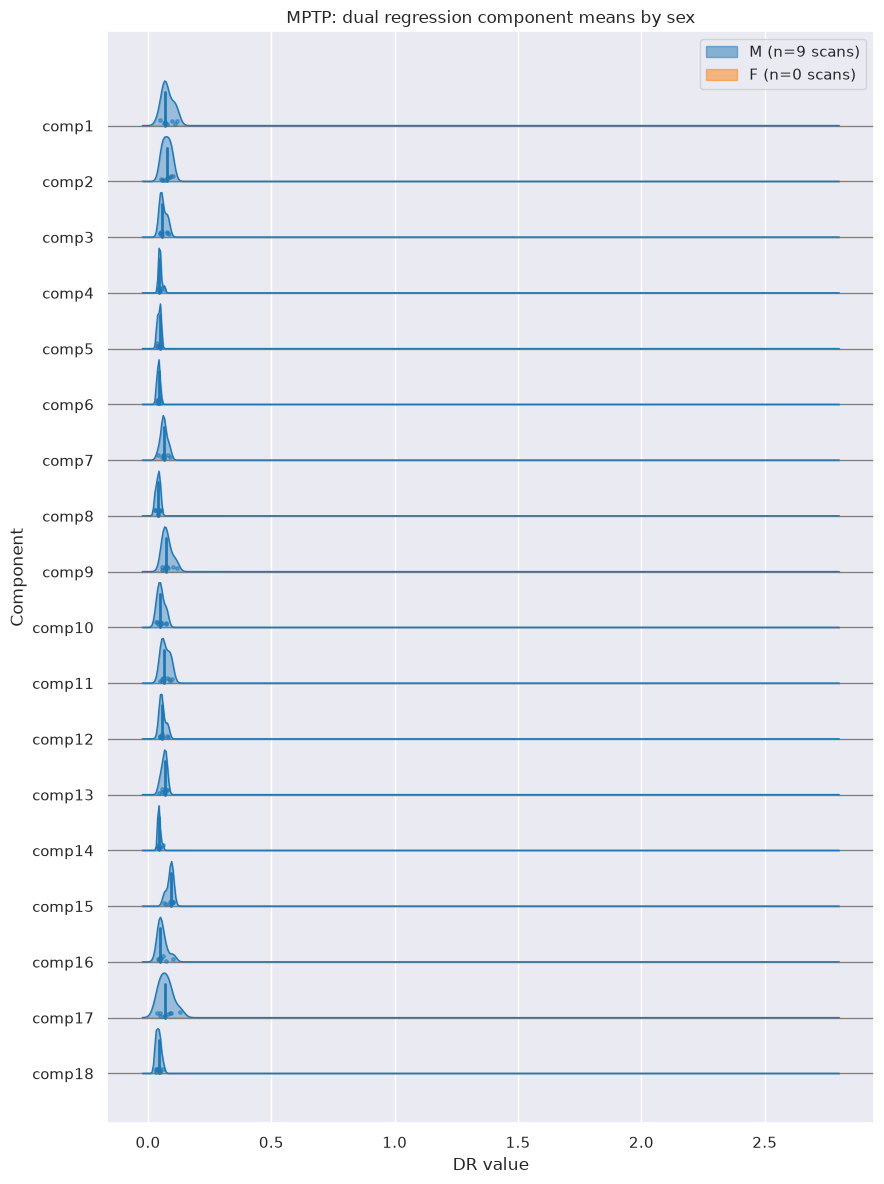

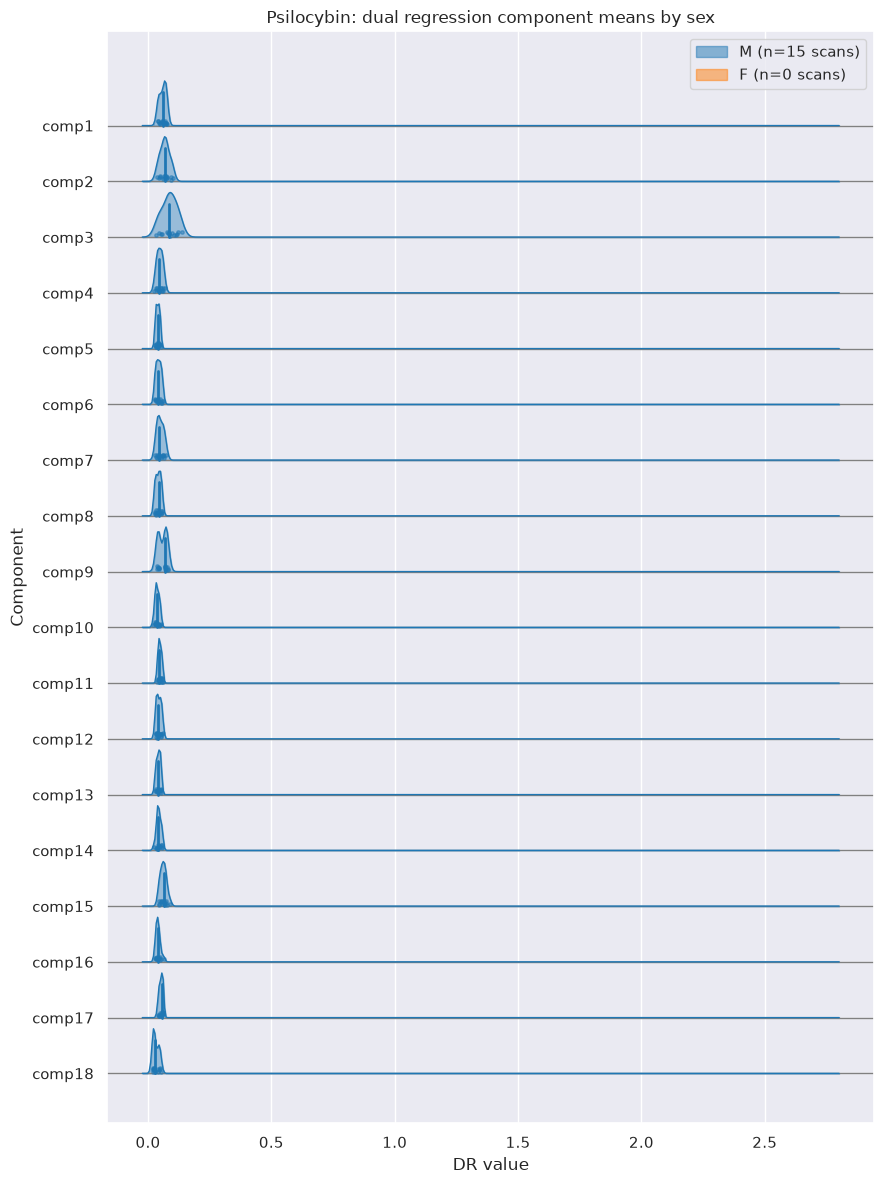

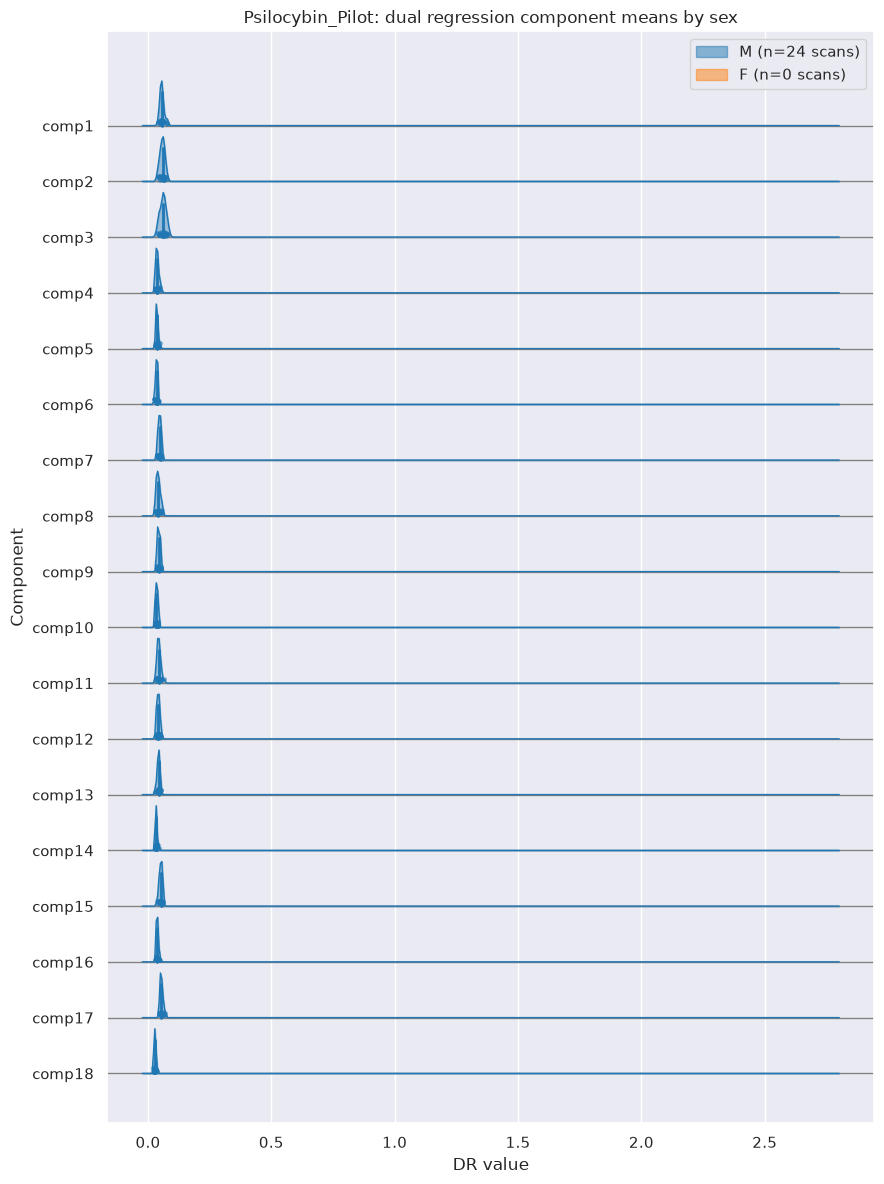

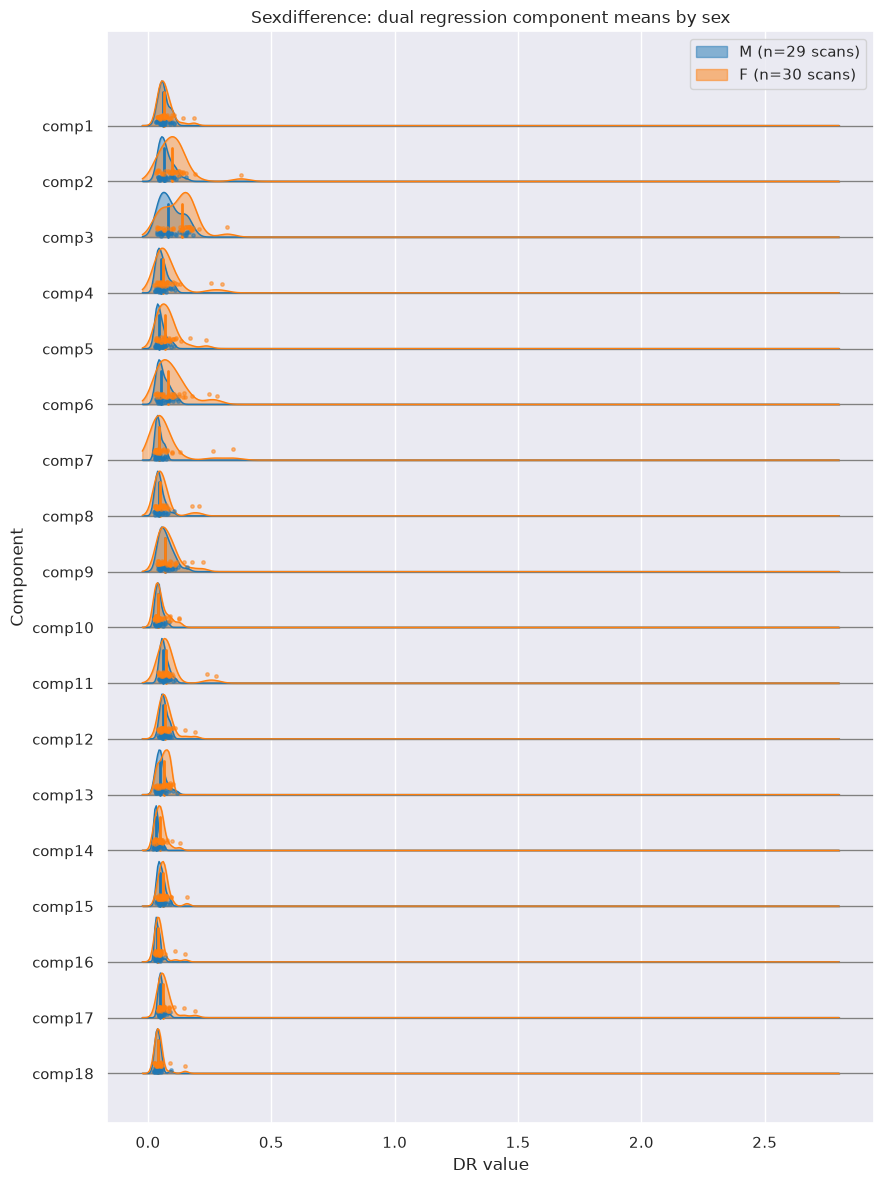

In [4]:
# Ridge plot of all components by sex
sex_colors = {"M": "tab:blue", "F": "tab:orange"}

# Same x range for every figure, so the datasets are directly comparable
x_grid = np.linspace(df[comp_cols].min().min(), df[comp_cols].max().max(), 500)

def ridge_plot(data, title):
    fig, ax = plt.subplots(figsize=(9, 12))
    rng = np.random.default_rng(0)

    for i, comp in enumerate(comp_cols[::-1]):  # comp1 at the top
        ax.axhline(i, color="grey", lw=1)

        for j, (sex, color) in enumerate(sex_colors.items()):
            values = data.loc[data["Sex"] == sex, comp].values
            if len(values) == 0:
                continue

            # KDE needs at least 2 points that are not all identical
            if len(values) > 1 and np.std(values) > 0:
                kde = gaussian_kde(values)(x_grid)
                kde = kde / kde.max() * 0.8
                ax.fill_between(x_grid, i, i + kde, color=color, alpha=0.4)
                ax.plot(x_grid, i + kde, color=color, lw=1)

            # Points: M slightly lower, F slightly higher, so they don't overlap
            jitter = rng.uniform(0.02, 0.1, size=len(values)) + j * 0.1
            ax.scatter(values, i + jitter, s=6, color=color, alpha=0.5, zorder=3)

            # Median per sex
            med = np.median(values)
            ax.plot([med, med], [i, i + 0.6], color=color, lw=2)

    ax.set_yticks(range(len(comp_cols)))
    ax.set_yticklabels(comp_cols[::-1])
    ax.set_xlabel("DR value")
    ax.set_ylabel("Component")
    ax.set_title(title)

    n_per_sex = data["Sex"].value_counts()
    ax.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.5) for c in sex_colors.values()],
        labels=[f"{s} (n={n_per_sex.get(s, 0)} scans)" for s in sex_colors],
    )
    plt.tight_layout()
    plt.show()

# All datasets together
ridge_plot(df, "All datasets: dual regression component means by sex")

# One figure per dataset
for name in df["dataset"].unique():
    ridge_plot(df[df["dataset"] == name], f"{name}: dual regression component means by sex")

Train: 1561 scans, 332 mice
Test:  356 scans, 84 mice
Overlap: set()


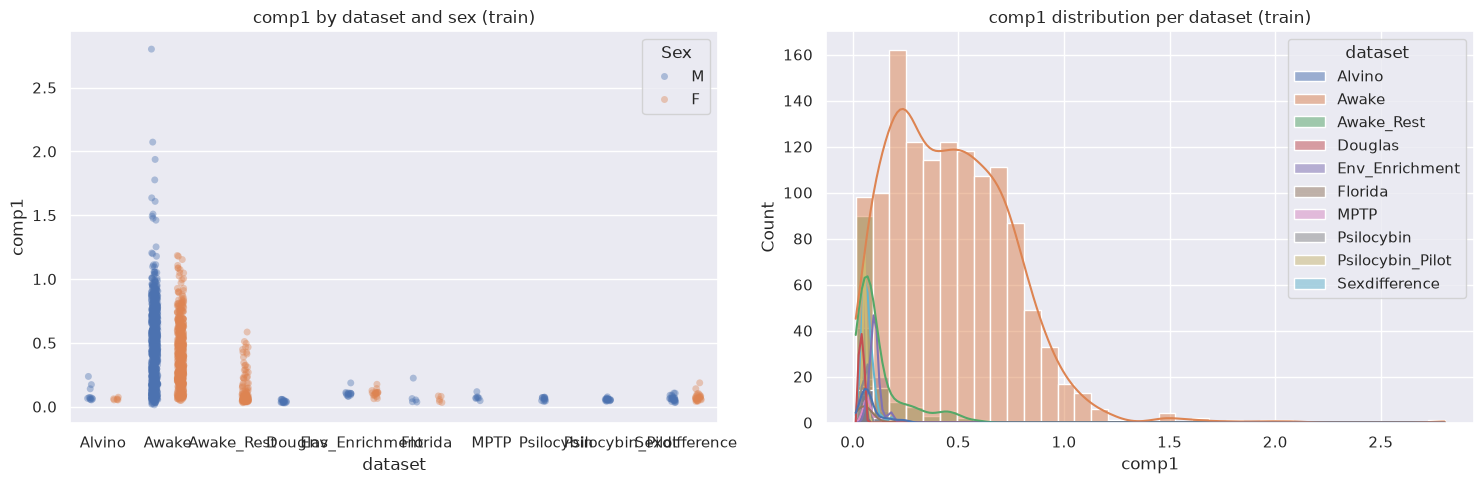

In [5]:
# Split train/test by mouse, stratified by dataset and sex
rng = np.random.default_rng(42)  # fixed seed
test_frac = 0.2

test_mice = []
for _, group in mice.groupby(["dataset", "Sex"]):
    ids = group["mouse_id"].values
    n_test = int(round(test_frac * len(ids)))
    test_mice.extend(rng.choice(ids, size=n_test, replace=False))

is_test = df["mouse_id"].isin(test_mice)
train_df = df[~is_test].copy()
test_df = df[is_test].copy()

print("Train:", len(train_df), "scans,", train_df["mouse_id"].nunique(), "mice")
print("Test: ", len(test_df), "scans,", test_df["mouse_id"].nunique(), "mice")
print("Overlap:", set(train_df["mouse_id"]) & set(test_df["mouse_id"]))


# NormData
covariates = ["sex_encoded"]
batch_effects = ["dataset"]
feature_to_model = comp_cols[:9]  # test with 9 components first, then comp_cols

train = NormData.from_dataframe(
    name="train",
    dataframe=train_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)
test = NormData.from_dataframe(
    name="test",
    dataframe=test_df,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=feature_to_model,
    remove_Nan=False,
)

# Visualize one component as a check
feature_to_plot = feature_to_model[0]
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(data=train_df, x="dataset", y=feature_to_plot, hue="Sex", dodge=True, alpha=0.4, ax=ax[0])
ax[0].set_title(f"{feature_to_plot} by dataset and sex (train)")

sns.histplot(data=train_df, x=feature_to_plot, hue="dataset", kde=True, ax=ax[1])
ax[1].set_title(f"{feature_to_plot} distribution per dataset (train)")

plt.tight_layout()
plt.show()

In [6]:
# Initialize and Fit Normative Model: HBR with SHASH likelihood
# Mean: linear in sex, intercept varies per dataset
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
)

# Spread: linear in sex, intercept varies per dataset
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

# Skewness and tail heaviness
epsilon = make_prior(dist_name="Normal", dist_params=(0.0, 1.0))
delta = make_prior(dist_name="Normal", dist_params=(1.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0, 0.6))

model = NormativeModel(
    HBR(
        name="hbr_shashb",
        likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
        draws=500,  # 1500 for the final run
        tune=500,
        chains=4,
        cores=4,
        progressbar=True,
    ),
    inscaler="standardize",
    outscaler="standardize",
)

model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,3,0.11,63
,1000,3,0.10,95
,1000,2,0.12,127
,1000,0,0.12,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.22,63
,1000,0,0.21,63
,1000,0,0.22,31
,1000,0,0.22,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.23,15
,1000,0,0.23,15
,1000,0,0.25,15
,1000,3,0.23,63


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.15,127
,1000,0,0.16,111
,1000,0,0.15,31
,1000,0,0.13,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.21,15
,1000,0,0.18,63
,1000,1,0.22,63
,1000,0,0.21,15


...

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.09,191
,1000,3,0.09,127
,1000,2,0.10,63
,1000,5,0.11,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.24,31
,1000,0,0.20,63
,1000,0,0.24,15
,1000,0,0.20,95


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.18,31
,1000,0,0.18,31
,1000,2,0.19,63
,1000,1,0.20,15


/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decoration

<xarray.NormData> Size: 289kB
Dimensions:            (observations: 356, response_vars: 9, covariates: 1,
                        batch_effect_dims: 1, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 3kB 0 1 2 3 4 ... 352 353 354 355
  * response_vars      (response_vars) <U5 180B 'comp1' 'comp2' ... 'comp9'
  * covariates         (covariates) <U11 44B 'sex_encoded'
  * batch_effect_dims  (batch_effect_dims) <U7 28B 'dataset'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 3kB 0 1 2 3 4 ... 352 353 354 355
    Y                  (observations, response_vars) float64 26kB 0.1028 ... ...
    X                  (observations, covariates) float64 3kB 1.0 0.0 ... 0.0
    batch_effects      (observations, batch_effect_dims) <U16 23kB 'Alvino' ....
    Z                  (observations, response_vars) float64 26kB 0.476 ... 0...
    centiles           (centile, observations, response_vars) float64 128kB 0...
    baseline_logp      (observations, response_vars) float64 26kB -1.103 ... ...
    logp               (observations, response_vars) float64 26kB 0.6919 ... ...
    Yhat               (observations, response_vars) float64 26kB 0.09069 ......
    statistics         (response_vars, statistic) float64 936B 0.179 ... 0.378
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           test
    unique_batch_effects:           {np.str_('dataset'): ['Alvino', 'Awake', ...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('sex_encoded'): {'min': 0.0, 'ma...
    batch_effect_covariate_ranges:  {np.str_('dataset'): {'Alvino': {np.str_(...

In [7]:
dir(model);
print([a for a in dir(model) if not a.startswith("_")])

['batch_effect_counts', 'batch_effect_covariate_ranges', 'batch_effect_dims', 'batch_effects_maps', 'check_compatibility', 'compute_baseline_logp', 'compute_centiles', 'compute_correlation_matrix', 'compute_logp', 'compute_thrivelines', 'compute_yhat', 'compute_zscores', 'correlation_matrix', 'covariate_ranges', 'covariates', 'elemwise_logp_baseline_model', 'evaluate', 'evaluate_model', 'evaluator', 'extend', 'extend_predict', 'extract_data', 'fit', 'fit_predict', 'from_args', 'harmonize', 'has_batch_effect', 'inscaler', 'inscalers', 'is_fitted', 'load', 'map_batch_effects', 'merge', 'model_specific_evaluation', 'n_fit_observations', 'name', 'outscaler', 'outscalers', 'postprocess', 'predict', 'preprocess', 'register_batch_effects', 'register_data_info', 'regression_models', 'response_vars', 'sample_batch_effects', 'sample_covariates', 'save', 'save_dir', 'savemodel', 'saveplots', 'saveresults', 'scale_backward', 'scale_forward', 'set_ensure_save_dirs', 'set_save_dir', 'synthesize', 't

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


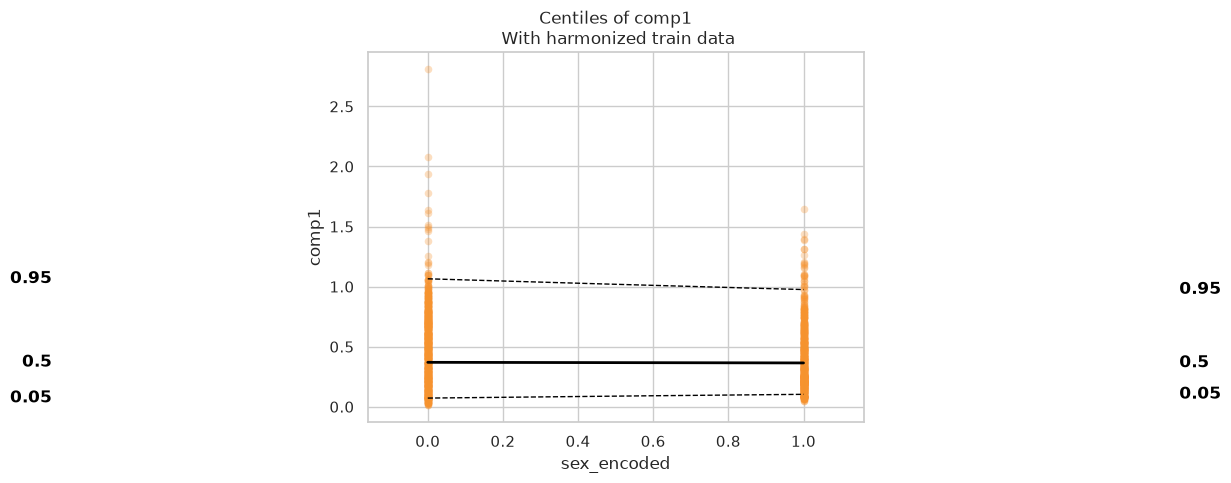

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


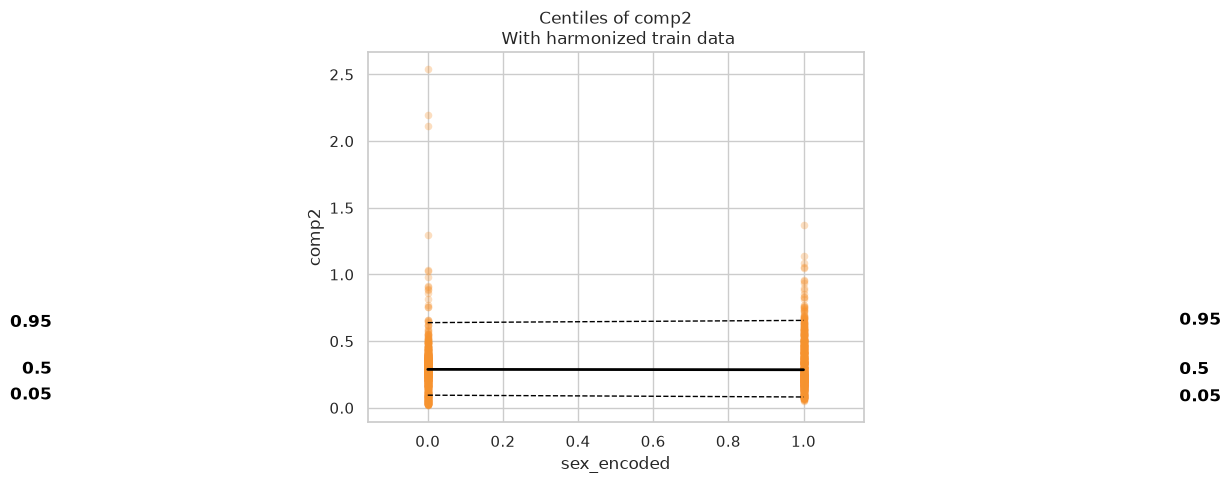

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


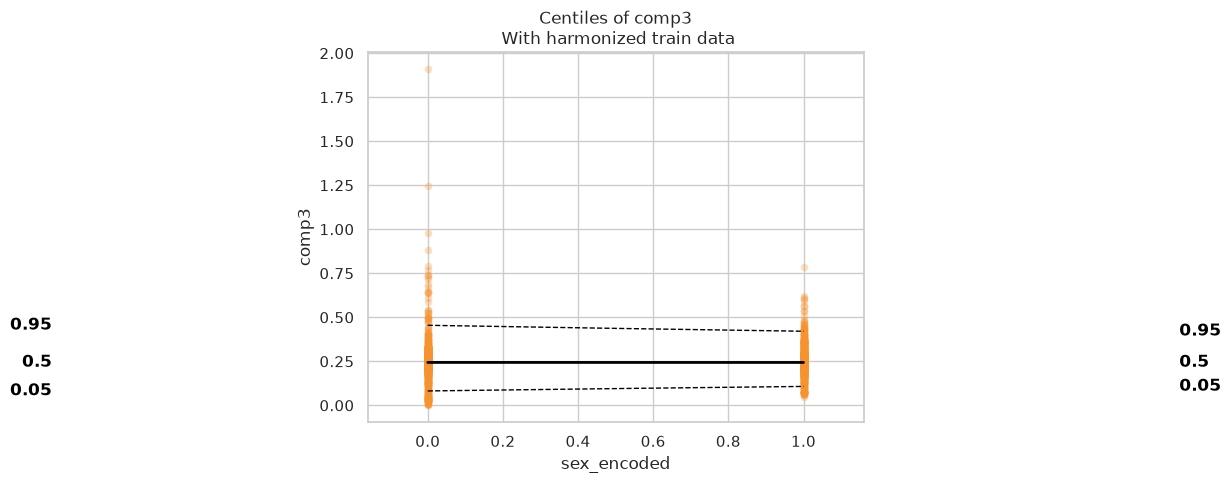

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


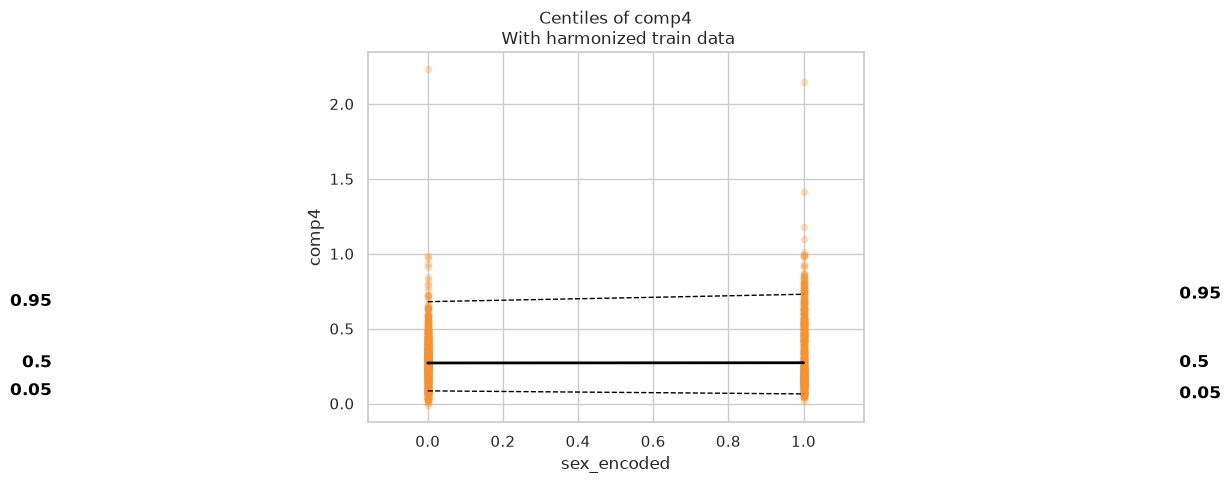

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


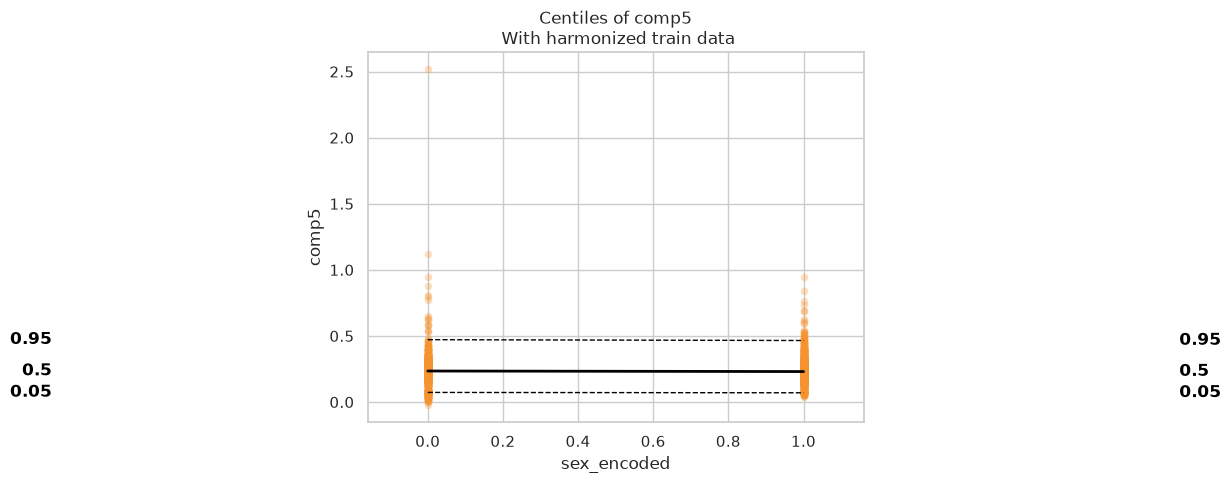

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


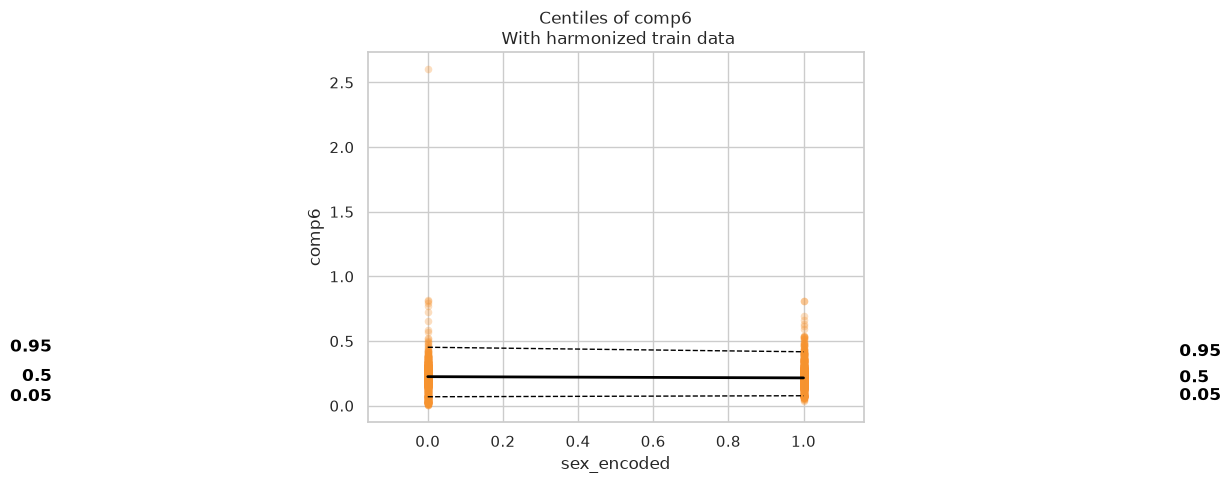

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


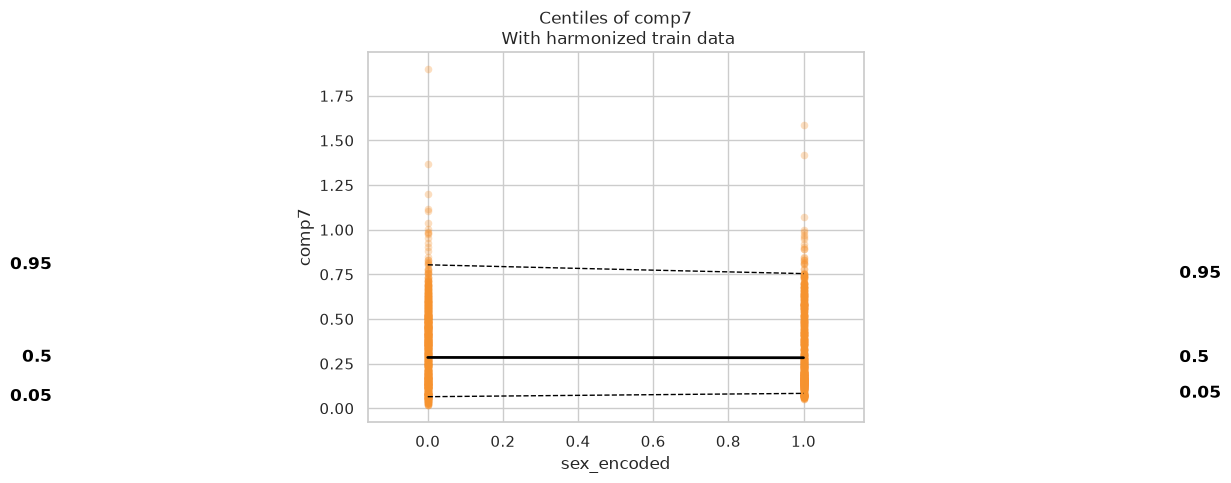

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


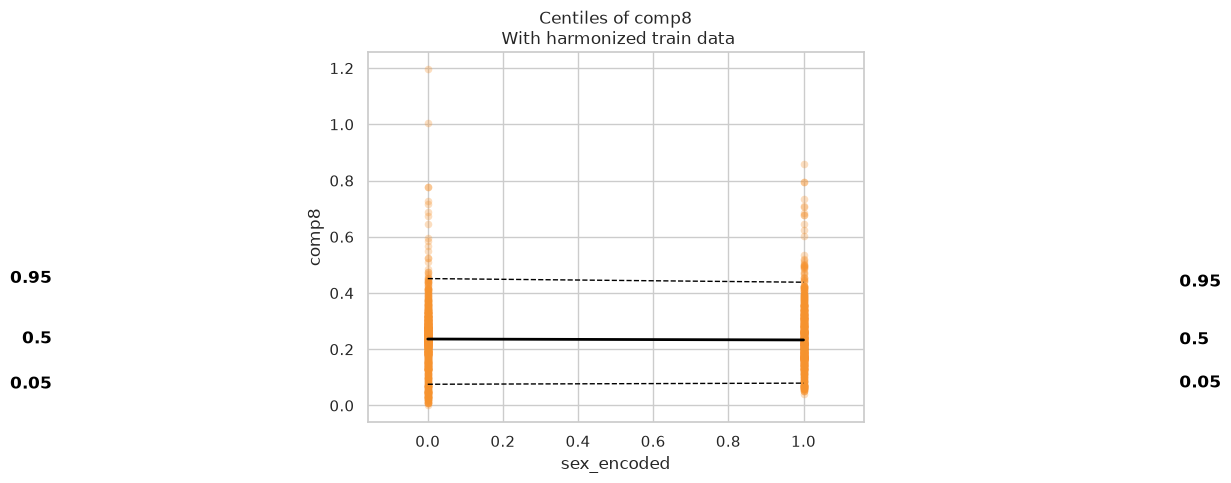

/home/traaffneu/bersal/.conda/envs/pcn_env/lib/python3.11/site-packages/pcntoolkit/util/plotter.py:263: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


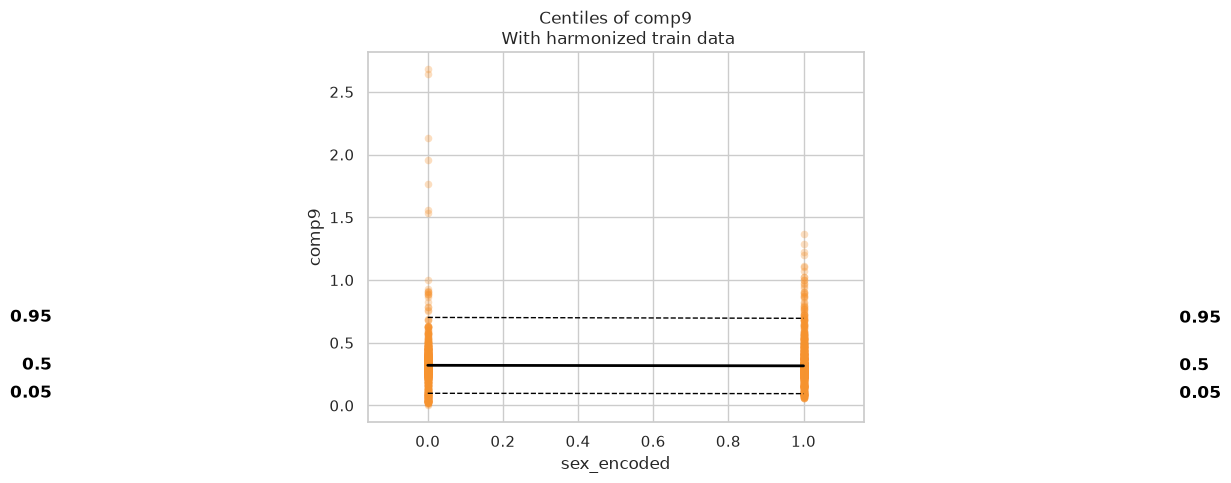

In [8]:
# Evaluation
#in NormData I selected only comp1 and comp 2 for now
# Centile plots
for comp in feature_to_model:
    plot_centiles(
        model,
        scatter_data=train,
        response_vars=[comp],
        centiles=[0.05, 0.5, 0.95],
        covariate="sex_encoded",
        scatter_kwargs={"s": 30, "alpha": 0.3},
    )

In [9]:
# Statistics
print("Train set statistics:")
display(train.get_statistics_df().loc[feature_to_model])
print("Test set statistics:")
display(test.get_statistics_df().loc[feature_to_model])

Train set statistics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
comp1,0.236206,1.297347,0.089695,0.981182,0.931866,-0.487073,0.233327,0.261317,0.517041,1.935394e-107,0.766673,0.983366,0.111149
comp2,0.197483,2.514755,0.062543,0.706565,0.966571,-0.452367,0.195488,0.167384,0.368933,1.605138e-51,0.804512,0.973037,0.465096
comp3,0.200365,2.427828,0.065703,0.922193,1.051039,-0.367900,0.199139,0.111052,0.338865,3.025941e-43,0.800861,0.972270,0.420342
comp4,0.225347,1.915082,0.077831,0.852242,0.982606,-0.436333,0.225293,0.173849,0.468803,4.153843e-86,0.774707,0.984182,0.240392
comp5,0.242834,4.615732,0.060378,1.432331,0.953543,-0.465396,0.241096,0.119236,0.421789,2.292346e-68,0.758904,0.964805,0.604532
comp6,0.214218,5.270611,0.061384,0.737272,0.999608,-0.419330,0.212758,0.112438,0.420064,9.111261e-68,0.787242,0.963844,0.615228
comp7,0.219246,0.755247,0.108834,0.932630,0.997986,-0.420952,0.215936,0.197311,0.429490,4.388492e-71,0.784064,0.986190,0.057646
comp8,0.265928,1.120523,0.073455,0.819320,1.073711,-0.345227,0.264803,0.105351,0.390536,4.896159e-58,0.735197,0.981427,0.296632
comp9,0.193753,2.454580,0.069821,0.882244,0.919243,-0.499695,0.190114,0.189450,0.377313,5.451098e-54,0.809886,0.965032,0.541814


Test set statistics:


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
comp1,0.178958,-0.292838,0.127897,1.254297,0.740569,-0.546022,0.125738,0.244458,0.515179,1.591844e-25,0.874262,0.980116,0.210475
comp2,0.170492,0.152641,0.128586,0.730246,1.038655,-0.428749,0.168038,0.178668,0.417845,1.780849e-16,0.831962,0.979493,0.505778
comp3,0.248973,-0.234070,0.098590,0.900900,1.006598,-0.293248,0.244358,0.095760,0.380739,1.002275e-13,0.755642,0.994166,0.172493
comp4,0.154482,-0.383952,0.116388,1.413375,0.928414,-0.491492,0.124016,0.185043,0.419002,1.442913e-16,0.875984,0.981659,0.281576
comp5,0.195462,-0.190238,0.113147,2.880838,1.063916,-0.302020,0.169281,0.118310,0.442300,1.747093e-18,0.830719,0.970280,0.538857
comp6,0.220619,-0.590316,0.114432,0.792898,1.026308,-0.281054,0.197015,0.101568,0.430598,1.673542e-17,0.802985,0.979979,0.290678
comp7,0.149376,-0.470597,0.160633,1.253307,0.814748,-0.514007,0.098672,0.193309,0.443407,1.404248e-18,0.901328,0.988082,0.149705
comp8,0.181668,1.128190,0.110378,0.811263,1.270116,-0.294341,0.174882,0.129090,0.473957,2.454124e-21,0.825118,0.958984,0.668176
comp9,0.193433,-0.429319,0.110568,0.968857,0.974833,-0.354881,0.166693,0.175766,0.451622,2.710180e-19,0.833307,0.974828,0.378049


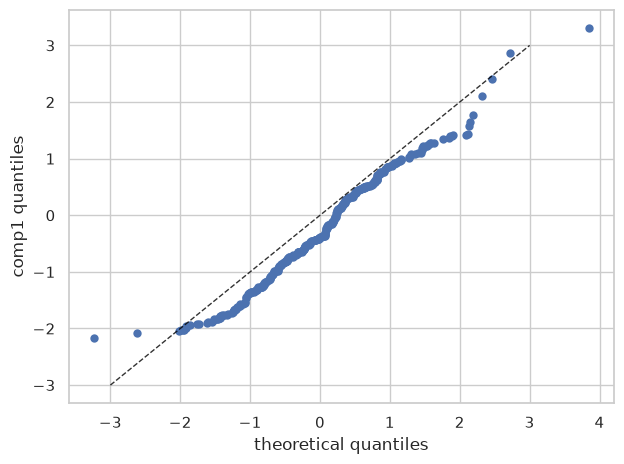

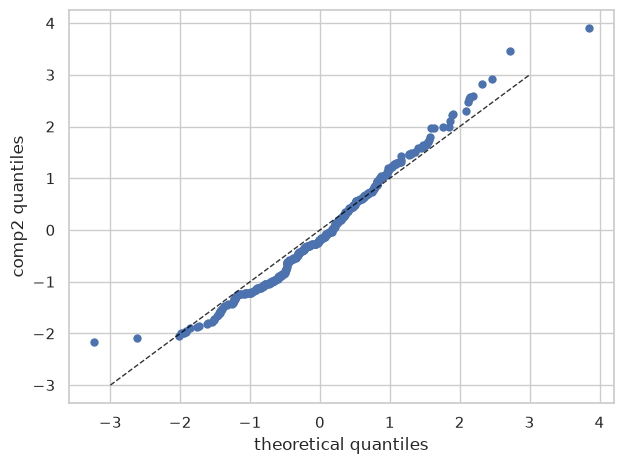

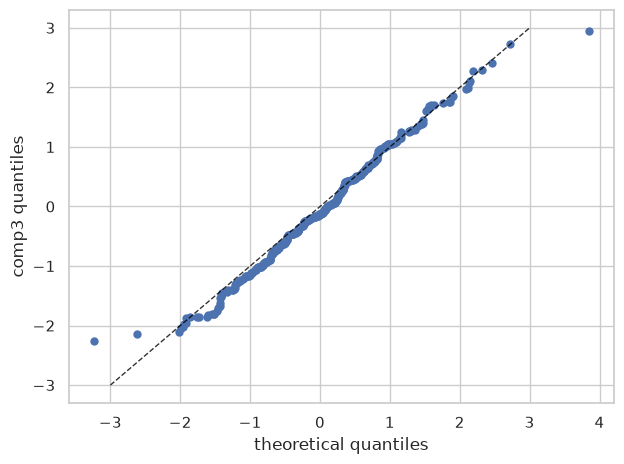

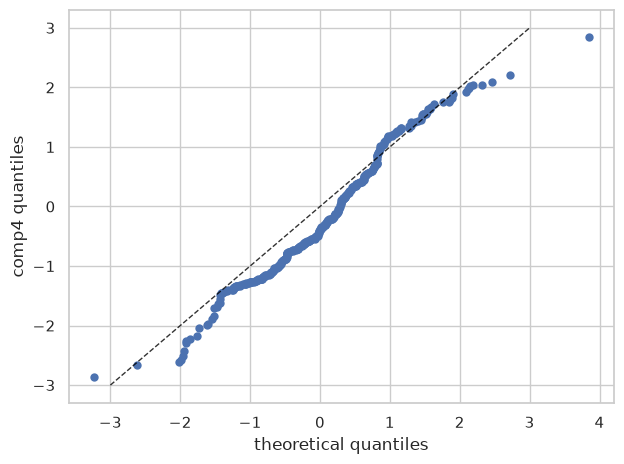

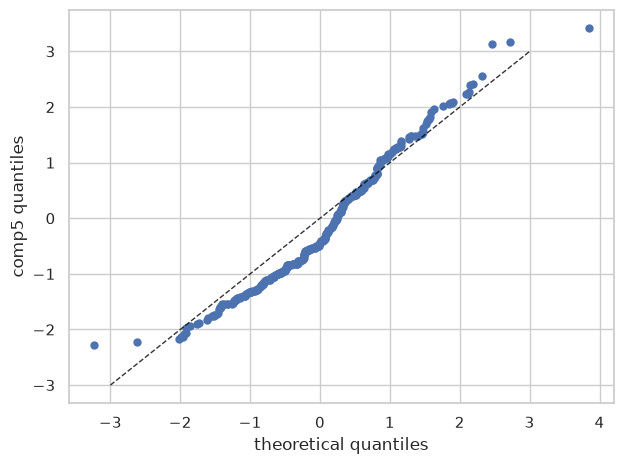

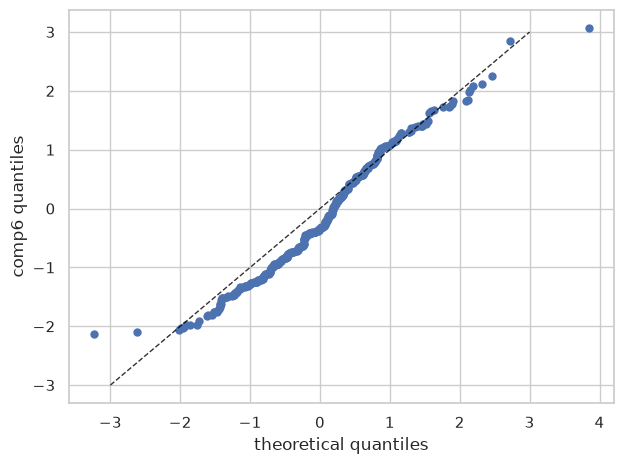

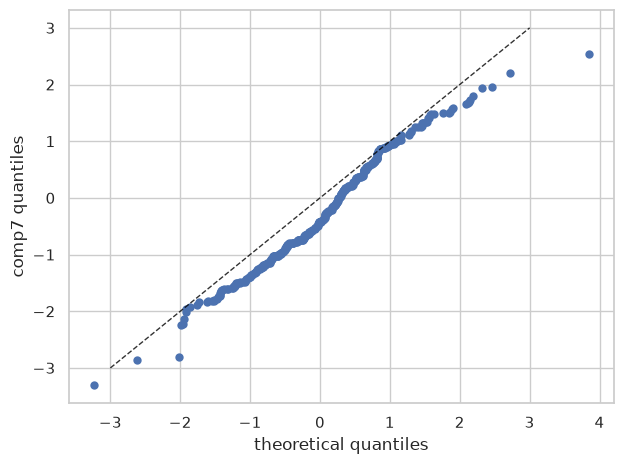

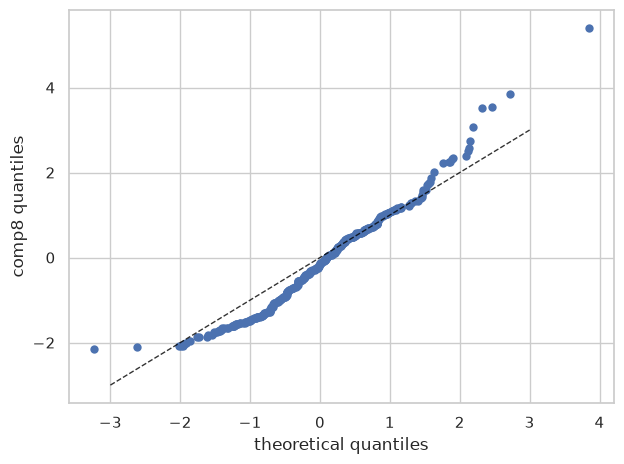

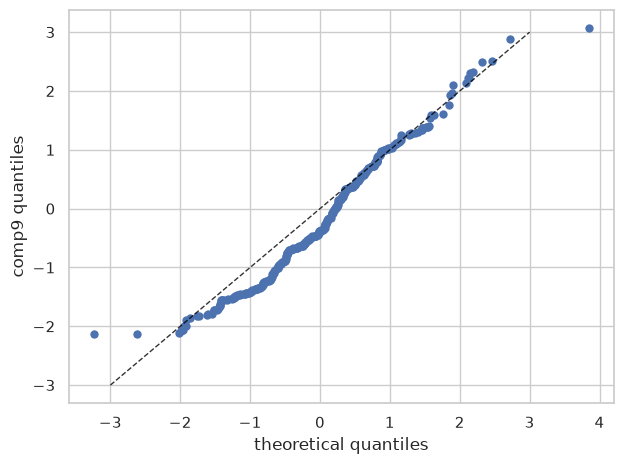

In [10]:
# QQ plots
for comp in feature_to_model:
    plot_qq(test.sel({"response_vars": [comp]}), plot_id_line=True)